In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip3 install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 25.4 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

## Load in Data

In [ ]:
# import csv
path = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_insole_sensor_df.csv"

interpolated_final_df = pd.read_csv(path)

In [ ]:
# reconstructing variables from the gait_cycle_id
interpolated_final_df['participant_id'] = interpolated_final_df['gait_cycle_id'].str.split('_').str[0]
interpolated_final_df['left_gait_cycle'] = interpolated_final_df['gait_cycle_id'].str.split('_').str[1]
interpolated_final_df['task'] = interpolated_final_df['gait_cycle_id'].str.split('_').str[2]

In [ ]:
# sort values of df
interpolated_final_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [ ]:
# normalization isnt needed here because there is already the normalized variables within the df
# multiplied by 1000 to remove the use of floats, for potential memory size
interpolated_final_df['time'] = (interpolated_final_df['time'] * 1000).astype(int)
interpolated_final_df['Left_norm'] = (interpolated_final_df['Left_norm'] * 1000).astype(int)
interpolated_final_df['Right_norm'] = (interpolated_final_df['Right_norm'] * 1000).astype(int)
interpolated_final_df['Left_norm_cumulative'] = (interpolated_final_df['Left_norm_cumulative'] * 1000).astype(int)
interpolated_final_df['Right_norm_cumulative'] = (interpolated_final_df['Right_norm_cumulative'] * 1000).astype(int)

In [ ]:
# convert string variables to numerical substitutes
le = LabelEncoder()
interpolated_final_df['task'] = le.fit_transform(interpolated_final_df['task'])
interpolated_final_df['walk_mode'] = le.fit_transform(interpolated_final_df['walk_mode'])

In [ ]:
# removal of raw values
interpolated_final_df = interpolated_final_df.drop(columns=['Left_raw', 'Right_raw'])

In [ ]:
# Define columns to be converted to integers, excluding sensor_location and gait_cycle_id
columns_to_convert = ['participant_id', 'task', 'time', 'Left_norm',
                      'Right_norm', 'Left_norm_cumulative',
                      'Right_norm_cumulative', 'walk_mode']

# Convert specified columns to integer
interpolated_final_df[columns_to_convert] = interpolated_final_df[columns_to_convert].astype(int)

# Handle 'left_gait_cycle' separately (convert only the part before the decimal)
interpolated_final_df['left_gait_cycle'] = (
    interpolated_final_df['left_gait_cycle']
    .str.split('.')
    .str[0]
    .astype(int)
)


In [ ]:
import random

# train/val/test split by subject
number_list = list(interpolated_final_df['participant_id'].unique())
# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[25, 15]
[5, 16]
[1, 10, 12, 13, 14, 17, 18, 19, 2, 22, 23, 24, 3, 4, 7, 8]


In [ ]:
# define the various splits
train = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(train_list)]
val = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(val_three_numbers)]
test = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(test_three_numbers)]

In [ ]:
# retain only the first instance of gait_cycle_id
train_gc = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [ ]:
# count how many unique gait cycle ids are in each walk mode
train_gc[['walk_mode']].value_counts()

,count
walk_mode,
4,13737
0,4551
1,3299
3,1718
2,914


In [ ]:
# Oversample smaller classes to balance the dataset
min_samples = int(train_gc['walk_mode'].value_counts().min())

In [ ]:
# Downsample to balance classes
balanced_gait_cycles = (
    train_gc.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)

<ipython-input-18-20f7be106a20>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [ ]:
print(balanced_gait_cycles['walk_mode'].value_counts())

walk_mode
0    914
1    914
2    914
3    914
4    914
Name: count, dtype: int64


In [ ]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [ ]:
train = filtered_interpolated_final_df.copy()

In [ ]:
le = LabelEncoder()

# convert values to numerical labels
train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

<ipython-input-22-b990848ca3d9>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
<ipython-input-22-b990848ca3d9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['sensor_location'] = le.fit_transform(val['sensor_location'])
<ipython-input-22-b990848ca3d9>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [ ]:
train['walk_mode'].value_counts()

,count
walk_mode,
2,584960
4,584960
3,584960
0,584960
1,584960


In [ ]:
def preprocess_data(df):
    all_data_x = []
    all_labels_y = []

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Prepare a 2D array to hold data for the current gait cycle (80, 18)
        segment_data = []

        # Group by sensor location and extract data in the desired order
        sensor_data_dict = {}
        for sensor_location, sensor_data in group_data.groupby('sensor_location'):
            sensor_array = sensor_data[['Left_norm', 'Right_norm']].values
            sensor_data_dict[sensor_location] = sensor_array

        # Ensure all sensor data has the same time length (80)
        for sensor_location in sorted(sensor_data_dict.keys()):
            sensor_array = sensor_data_dict[sensor_location]
            if len(sensor_array) < 80:
                # Pad with zeros if shorter
                padding = np.zeros((80 - len(sensor_array), 2))
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                # Truncate if longer
                sensor_array = sensor_array[:80]

            segment_data.append(sensor_array)

        # Add cumulative data
        cumulative_data = group_data[['Left_norm_cumulative', 'Right_norm_cumulative']].values[:80]
        if len(cumulative_data) < 80:
            padding = np.zeros((80 - len(cumulative_data), 2))
            cumulative_data = np.vstack([cumulative_data, padding])

        segment_data.append(cumulative_data)

        # Combine all sensor data into the final 2D array for the segment (80, 18)
        segment_data = np.hstack(segment_data)
        all_data_x.append(segment_data)

        # Extract labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding

        all_labels_y.append(walk_mode_data)

    # Convert lists to NumPy arrays
    all_data_x = np.array(all_data_x)  # Shape: [x, 80, 18]
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_data_x, all_labels_y


In [ ]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

In [ ]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

In [ ]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

In [ ]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [ ]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [ ]:
train_all_labels_y.shape, train_all_labels_y[0]

((4570, 5), array([0., 0., 1., 0., 0.]))

In [ ]:
train_all_data_x.shape, train_all_labels_y.shape, val_all_data_x.shape, val_all_labels_y.shape, test_all_data_x.shape, test_all_labels_y.shape

((4570, 80, 18),
 (4570, 5),
 (2993, 80, 18),
 (2993, 5),
 (3252, 80, 18),
 (3252, 5))

In [ ]:
train_X = train_all_data_x
train_Y = train_all_labels_y

val_X = val_all_data_x
val_Y = val_all_labels_y

test_X = test_all_data_x
test_Y = test_all_labels_y

In [ ]:
n_obs, n_timesteps, n_features, n_classes = train_X.shape[0], train_X.shape[1], train_X.shape[2], train_Y.shape[1]

In [ ]:
n_obs, n_timesteps, n_features, n_classes

(4570, 80, 18, 5)

## hyperparameter tuning

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 9.6 MB/s eta 0:00:00


In [ ]:
# # Clears the session for TensorFlow
tf.keras.backend.clear_session()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import Hyperband

# Function to build model for Keras Tuner
def build_model(hp):
    input_shape = (80, 18)
    inputs = Input(shape=input_shape)

    # CNN layer
    cnn_out = BatchNormalization()(inputs)
    cnn_out = Conv1D(
            filters=hp.Int('filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('kernel_size', values=[3, 5]),
            activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(hp.Float('cnn_dropout', 0.3, 0.5, step=0.05))(cnn_out)


    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(
        units=hp.Int('lstm_units', min_value=64, max_value=256, step=64),
        dropout=hp.Float('lstm_dropout', 0.3, 0.5, step=0.05),
        recurrent_dropout=hp.Float('recurrent_dropout', 0.3, 0.5, step=0.05),
        return_sequences=True  # Return sequences for Attention layer
    ))(cnn_out)

    # Attention layer
    attention = Attention()([lstm_out, lstm_out])
    merged_output = Concatenate(axis=-1)([lstm_out, attention])

    # MLP layer
    mlp_out = Flatten()(merged_output)
    mlp_out = Dense(
        units=hp.Int('dense1_units', min_value=64, max_value=256, step=64),
        activation='relu'
    )(mlp_out)
    mlp_out = Dense(
        units=hp.Int('dense2_units', min_value=32, max_value=128, step=32),
        activation='relu'
    )(mlp_out)

    # Output layer with softmax activation for multi-class classification
    output_layer = Dense(n_classes, activation='softmax')(mlp_out)

    # Compile model
    model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Define Keras Tuner
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='keras_tuner_dir',
    project_name='cnn_lstm_tuning'
)

# Run the search
tuner.search(train_X, train_Y, validation_data=(val_X, val_Y), epochs=20, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

Trial 30 Complete [00h 03m 26s]
val_accuracy: 0.6658870577812195

Best val_accuracy So Far: 0.7704644203186035
Total elapsed time: 00h 57m 20s


## Train Model

In [ ]:
# print the summary of the best model
best_model.summary()

In [ ]:
# Build the model with the best hp
model = build_model(best_hps)

# Fit with the entire dataset
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(train_X, train_Y, epochs=100, batch_size=128, callbacks=[callback], validation_data=(val_X, val_Y))

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.3082 - loss: 3.1143 - val_accuracy: 0.2616 - val_loss: 1.5269
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5896 - loss: 1.0144 - val_accuracy: 0.5336 - val_loss: 1.0251
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.6727 - loss: 0.8341 - val_accuracy: 0.5827 - val_loss: 1.0099
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6936 - loss: 0.7666 - val_accuracy: 0.5917 - val_loss: 0.9926
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7293 - loss: 0.7223 - val_accuracy: 0.6425 - val_loss: 0.9103
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7715 - loss: 0.6158 - val_accuracy: 0.7000 - val_loss: 0.8418
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.7629 - loss: 0.6299 - val_accuracy: 0.6856 - val_loss: 0.9234
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7810 - loss: 0.6023 - val_accuracy: 

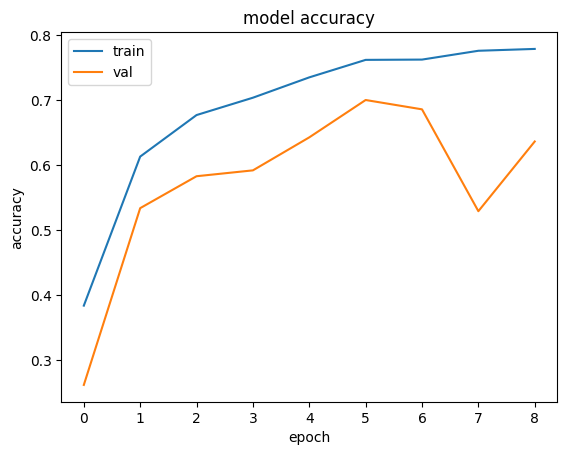

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

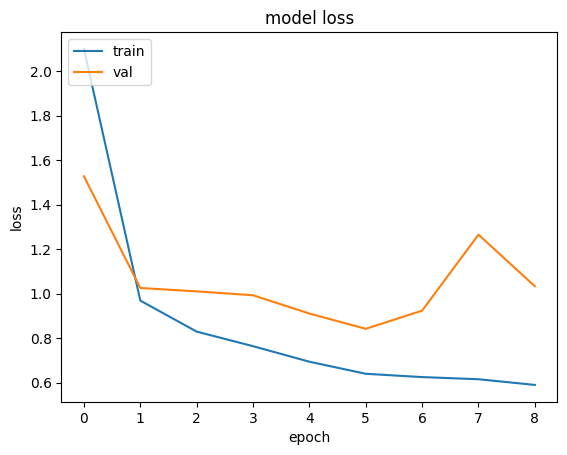

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_X, test_Y)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7310 - loss: 0.8765


In [ ]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X[0].shape)
print("Test Y shape:", test_Y[0].shape)

Test X shape: (80, 18)
Test Y shape: (5,)


In [ ]:
#predictions
predictions = model.predict(test_X)

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step


In [ ]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 74.29%
Predicted classes: [1 2 0 ... 0 4 1]
True classes: [4 2 0 ... 0 4 4]


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = predicted_classes
true_classes_np = true_classes

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)
print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)
print(" ")
# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
f1_scores = [round(item, 3) for item in f1_scores]
print(f"F1-Scores (per class): {f1_scores}")

# Custom calculation for specificity per class
specificities = []

for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    # round to 3 decimal points
    specificity = round(specificity, 3)
    specificities.append(specificity)

    sensitivity = recall_score(true_classes_np, predicted_classes_np, average=None)
    # round the sensitivity items to 3 decimal points
    sensitivity = [round(item, 3) for item in sensitivity]

print(f"Sensitivity (per class): {sensitivity}")
print(f"Specificities (per class): {specificities}")

# average sensitivity
average_sensitivity = np.mean(sensitivity)
print(f"Average sensitivity: {average_sensitivity}")

# average specificity
average_specificity = np.mean(specificities)
print(f"Average specificity: {average_specificity}")

# overall F1
overall_f1 = 2 * (average_sensitivity * average_specificity) / (average_sensitivity + average_specificity)
print(f"Overall F1: {overall_f1}")

Classification Report:
               precision    recall  f1-score   support

           0     0.7593    0.8983    0.8230       590
           1     0.4794    0.2943    0.3647       435
           2     0.5909    0.6319    0.6107       144
           3     0.7483    0.7668    0.7574       283
           4     0.7868    0.8056    0.7960      1800

    accuracy                         0.7429      3252
   macro avg     0.6729    0.6794    0.6704      3252
weighted avg     0.7286    0.7429    0.7317      3252

Confusion Matrix:
 [[ 530    0    0    2   58]
 [   6  128    1    2  298]
 [   2    1   91   35   15]
 [   9    5   30  217   22]
 [ 151  133   32   34 1450]]
 
F1-Scores (per class): [0.898, 0.294, 0.632, 0.767, 0.806]
Sensitivity (per class): [0.898, 0.294, 0.632, 0.767, 0.806]
Specificities (per class): [0.937, 0.951, 0.98, 0.975, 0.729]
Average sensitivity: 0.6794
Average specificity: 0.9144
Overall F1: 0.7795750533316602


## Confusion Matrix

In [ ]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

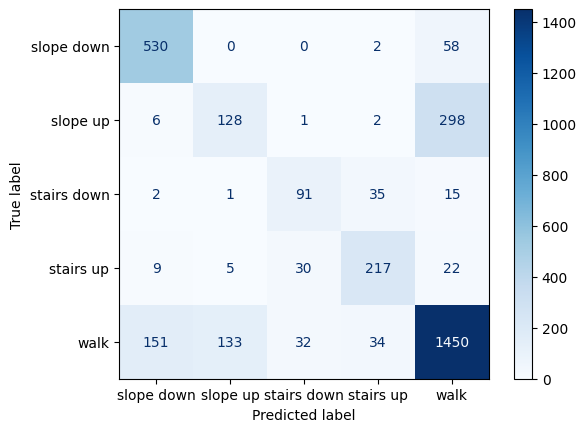

In [ ]:
# plot confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot(cmap=plt.cm.Blues)
plt.show()

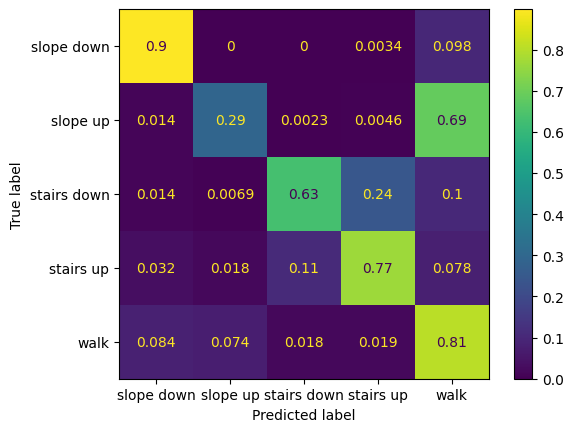

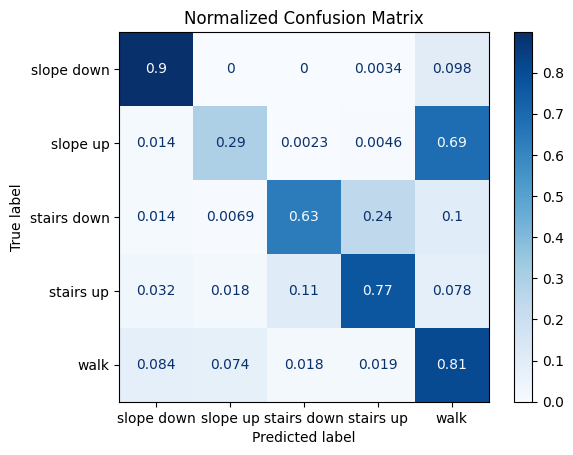

In [ ]:
# Create the normalized confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()